In [66]:
from datascience import *

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

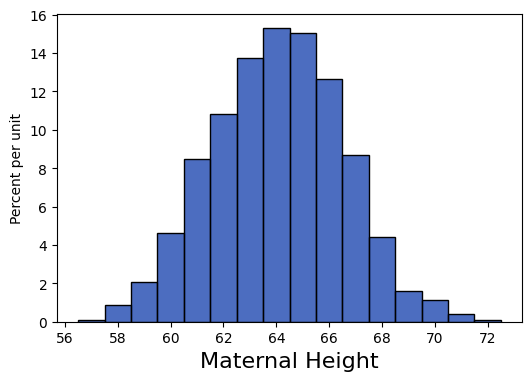

In [67]:
births = Table.read_table("baby.csv")
births.hist("Maternal Height", bins=np.arange(56.5, 72.6, 1))

In [68]:
heights = births.column("Maternal Height")
np.mean(heights), np.std(heights)

(64.049403747870528, 2.5250254409674375)

In [69]:
# Central Limit Theorem

united = Table.read_table("united.csv")
united.show(5)

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3
6/1/15,250,SAN,0
6/1/15,267,PHL,64


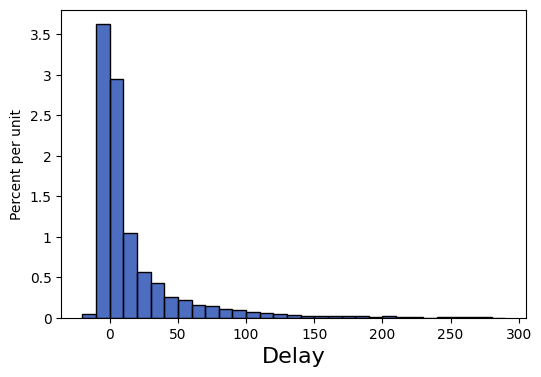

In [70]:
united_bins = np.arange(-20, 300, 10)
united.hist("Delay", bins=united_bins)

In [71]:
delays = united.column("Delay")
delay_mean = np.mean(delays)
delay_std = np.std(delays)
delay_median = np.median(delays)
delay_mean, delay_std, delay_median

(16.658155515370705, 39.480199851609314, 2.0)

In [72]:
def one_sample_mean(n):
    sampled_flights = united.sample(n)
    return np.mean(sampled_flights.column("Delay"))

In [73]:
one_sample_mean(100)

17.07

In [74]:
def ten_thousand_sample_means(n):
    means = make_array()
    for _ in range(10_000):
        means = np.append(means, one_sample_mean(n))

    return means

In [75]:
sample_means_100 = ten_thousand_sample_means(100)

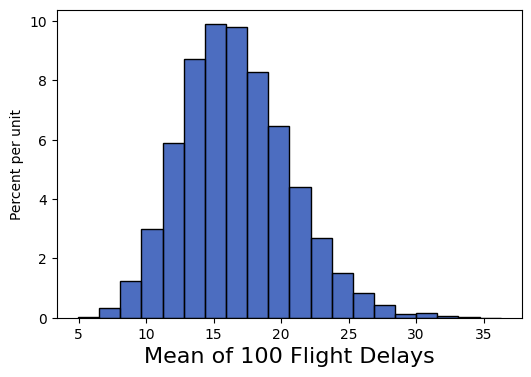

In [76]:
Table().with_column("Mean of 100 Flight Delays", sample_means_100).hist(bins=20)

In [77]:
sample_means_400 = ten_thousand_sample_means(400)

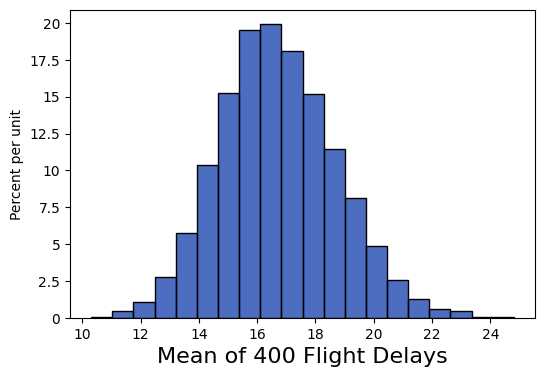

In [78]:
Table().with_column("Mean of 400 Flight Delays", sample_means_400).hist(bins=20)

In [79]:
np.mean(sample_means_100)

16.666347999999999

In [80]:
np.mean(sample_means_400)

16.7073535

In [81]:
sample_means_900 = ten_thousand_sample_means(900)

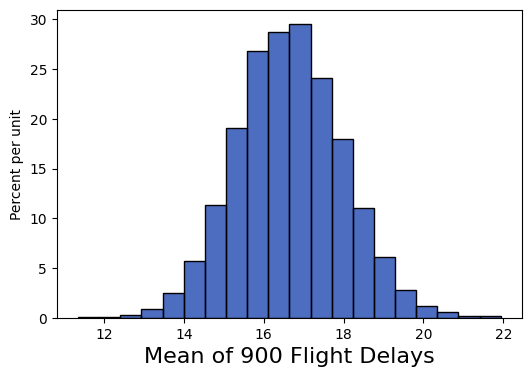

In [82]:
Table().with_column("Mean of 900 Flight Delays", sample_means_900).hist(bins=20)

In [83]:
sample_means_900 = ten_thousand_sample_means(1600)

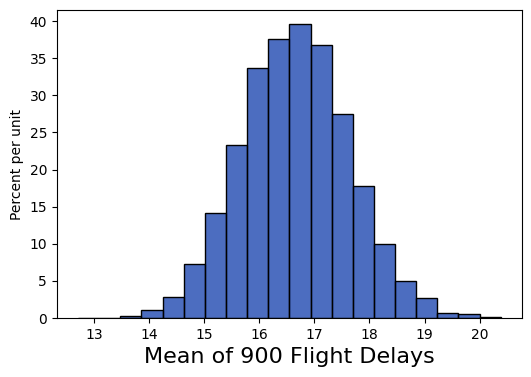

In [84]:
Table().with_column("Mean of 900 Flight Delays", sample_means_900).hist(bins=20)